In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/gpr_fwi_diffusion'
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())
print("Files in Drive:", os.listdir(PROJECT_DIR))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/gpr_fwi_diffusion
Files in Drive: ['groundtruth.png', 'observed_data.png', 'obs_data.npy', 'trace_cols.npy', 'gpr_synthetic_dataset.pt', 'loss_history.pt', 'diffusion_unet_weights.pt', 'loss_curves.npy', 'all_metrics.npy', 'inversion_results.npy', 'obs_data_hard.npy', 'trace_cols_hard.npy', 'inversion_results_hard.npy', 'all_metrics_hard.npy', 'figure5_comparison_preview.png', 'obs_data_v2.npy', 'trace_cols_v2.npy', 'all_metrics_v2.npy', 'inversion_results_v2.npy', 'obs_data_v3.npy', 'trace_cols_v3.npy', 'eps_true.npy', 'sig_true.npy', 'figure5_comparison_v3.png', 'inversion_results_v3.npy', 'figure5_comparison_400iter.png', 'all_metrics_v3.npy', 'figure5_final.png', 'eps_dry.npy', 'sig_dry.npy', 'eps_water.npy', 'sig_water.npy', 'eps_napl.npy', 'sig_napl.npy', 'obs_dry.npy', 'tc_dry.npy', 'obs_water.npy', 'tc_water.npy', 'obs_napl.npy', 'tc_napl.npy', 'eps_rec_dry.npy', 'sig_rec_dry.npy', 'eps_rec_water.npy', 'sig_rec

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

EPS_MIN, EPS_MAX = 2.0, 25.0
SIG_MIN, SIG_MAX = 0.0001, 0.05

def normalize(x, lo, hi):
    return 2 * (np.clip(x, lo, hi) - lo) / (hi - lo) - 1

def denormalize(x, lo, hi):
    return (x + 1) / 2 * (hi - lo) + lo

def gaussian_random_field(shape, scale=10.0, seed=None):
    rng = np.random.default_rng(seed)
    noise = rng.normal(size=shape)
    fy = np.fft.fftfreq(shape[0])[:, None]
    fx = np.fft.fftfreq(shape[1])[None, :]
    freq_radius = np.sqrt(fx**2 + fy**2)
    freq_radius[0, 0] = 1e-6
    filt = 1.0 / (1.0 + (freq_radius * scale) ** 2)
    field = np.fft.ifft2(np.fft.fft2(noise) * filt).real
    field -= field.mean()
    field /= field.std() + 1e-8
    return field

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = t[:, None].float() * emb[None, :]
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch), nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1))
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch), nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1))
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class SimpleUNet(nn.Module):
    def __init__(self, in_ch=2, base_ch=64, time_emb_dim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim), nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim))
        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)
        self.down1 = ResidualBlock(base_ch, base_ch, time_emb_dim)
        self.pool1 = nn.Conv2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.down2 = ResidualBlock(base_ch, base_ch*2, time_emb_dim)
        self.pool2 = nn.Conv2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.down3 = ResidualBlock(base_ch*2, base_ch*4, time_emb_dim)
        self.pool3 = nn.Conv2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.bottleneck = ResidualBlock(base_ch*4, base_ch*4, time_emb_dim)
        self.up3 = nn.ConvTranspose2d(base_ch*4, base_ch*4, 4, stride=2, padding=1)
        self.dec3 = ResidualBlock(base_ch*8, base_ch*2, time_emb_dim)
        self.up2 = nn.ConvTranspose2d(base_ch*2, base_ch*2, 4, stride=2, padding=1)
        self.dec2 = ResidualBlock(base_ch*4, base_ch, time_emb_dim)
        self.up1 = nn.ConvTranspose2d(base_ch, base_ch, 4, stride=2, padding=1)
        self.dec1 = ResidualBlock(base_ch*2, base_ch, time_emb_dim)
        self.out_conv = nn.Sequential(
            nn.GroupNorm(8, base_ch), nn.SiLU(),
            nn.Conv2d(base_ch, in_ch, 3, padding=1))
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x0 = self.in_conv(x)
        d1 = self.down1(x0, t_emb)
        d2 = self.down2(self.pool1(d1), t_emb)
        d3 = self.down3(self.pool2(d2), t_emb)
        b  = self.bottleneck(self.pool3(d3), t_emb)
        u3 = self.dec3(torch.cat([self.up3(b),  d3], dim=1), t_emb)
        u2 = self.dec2(torch.cat([self.up2(u3), d2], dim=1), t_emb)
        u1 = self.dec1(torch.cat([self.up1(u2), d1], dim=1), t_emb)
        return self.out_conv(u1)

class DiffusionSchedule:
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        self.timesteps = timesteps
        self.betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_ac   = self.sqrt_alphas_cumprod[t][:, None, None, None]
        sqrt_omac = self.sqrt_one_minus_alphas_cumprod[t][:, None, None, None]
        return sqrt_ac * x0 + sqrt_omac * noise

model    = SimpleUNet().to(device)
schedule = DiffusionSchedule(timesteps=1000, device=device)
model.load_state_dict(torch.load('diffusion_unet_weights.pt', map_location=device))
model.eval()
print("Diffusion model loaded.")

def forward_model(eps, sig, n_traces=32, noise_level=0.0):
    H, W = eps.shape
    t = np.linspace(-1, 1, 21)
    f0 = 0.3
    wavelet    = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    trace_cols = np.linspace(0, W-1, n_traces, dtype=int)
    data       = np.zeros((n_traces, H), dtype=np.float32)
    for i, col in enumerate(trace_cols):
        impedance   = 1.0 / np.sqrt(eps[:, col])
        refl        = np.diff(impedance, prepend=impedance[0])
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        data[i]     = np.convolve(refl * attenuation, wavelet, mode='same')
    if noise_level > 0:
        data += noise_level * np.std(data) * np.random.randn(*data.shape)
    return data.astype(np.float32), trace_cols

def compute_gradient(eps, sig, obs_data, trace_cols):
    H, W      = eps.shape
    t         = np.linspace(-1, 1, 21)
    f0        = 0.3
    wavelet   = (1 - 2*(np.pi*f0*t)**2) * np.exp(-(np.pi*f0*t)**2)
    pred_data = forward_model(eps, sig, n_traces=len(trace_cols))[0]
    residual  = pred_data - obs_data
    misfit    = 0.5 * np.sum(residual**2)
    grad_eps  = np.zeros_like(eps)
    grad_sig  = np.zeros_like(sig)
    for i, col in enumerate(trace_cols):
        adj         = np.convolve(residual[i], wavelet[::-1], mode='same')
        attenuation = np.exp(-np.cumsum(sig[:, col]) * 2.0)
        d_imp_d_eps = -0.5 / (eps[:, col]**1.5)
        for d in range(H):
            grad_eps[d, col] += adj[d] * attenuation[d] * d_imp_d_eps[d]
        for d in range(H):
            grad_sig[d, col] += -2.0 * adj[d] * attenuation[d] * \
                                  np.sum(adj[:d+1])
    return grad_eps, grad_sig, misfit

@torch.no_grad()
def diffusion_project_gentle(eps_arr, sig_arr, t_start=50):
    eps_n = normalize(eps_arr, EPS_MIN, EPS_MAX)
    sig_n = normalize(sig_arr, SIG_MIN, SIG_MAX)
    x0    = torch.from_numpy(
        np.stack([eps_n, sig_n], axis=0)[None]).float().to(device)
    t_tensor = torch.tensor([t_start], device=device)
    x        = schedule.q_sample(x0, t_tensor, torch.randn_like(x0))
    for t_cur in reversed(range(0, t_start)):
        t_cur_tensor = torch.tensor([t_cur], device=device)
        beta_t    = schedule.betas[t_cur]
        alpha_t   = schedule.alphas[t_cur]
        alpha_bar = schedule.alphas_cumprod[t_cur]
        pred_noise = model(x, t_cur_tensor)
        if t_cur > 0:
            coef = beta_t / torch.sqrt(1 - alpha_bar)
            x    = (1 / torch.sqrt(alpha_t)) * (x - coef * pred_noise)
        else:
            x = (x - torch.sqrt(1 - alpha_bar) * pred_noise) / \
                 torch.sqrt(alpha_bar)
            x = torch.clamp(x, -1, 1)
    x_d     = x.squeeze(0).cpu().numpy()
    eps_den = np.clip(denormalize(x_d[0], EPS_MIN, EPS_MAX), EPS_MIN, EPS_MAX)
    sig_den = np.clip(denormalize(x_d[1], SIG_MIN, SIG_MAX), SIG_MIN, SIG_MAX)
    return eps_den, sig_den

print("All definitions ready.")

Device: cuda
Diffusion model loaded.
All definitions ready.


In [3]:
from google.colab import files
uploaded = files.upload()

Saving 500chemicanmid.txt to 500chemicanmid.txt
Saving 500sand1.txt to 500sand1.txt
Saving 500watermid.txt to 500watermid.txt


In [4]:
import os
for f in ['500sand1.txt', '500watermid.txt', '500chemicanmid.txt']:
    size = os.path.getsize(f) / 1024
    print(f"{f}: {size:.0f} KB")

500sand1.txt: 689 KB
500watermid.txt: 712 KB
500chemicanmid.txt: 692 KB


Dry sand:  35 traces x 500 samples
Water:     38 traces x 500 samples
NAPL:      37 traces x 500 samples
Time window: 25.00 to 50.00 ns
Amplitude ranges:
  Dry sand: -0.00975 to 0.00712
  Water:    -0.00723 to 0.00528
  NAPL:     -0.00605 to 0.00486


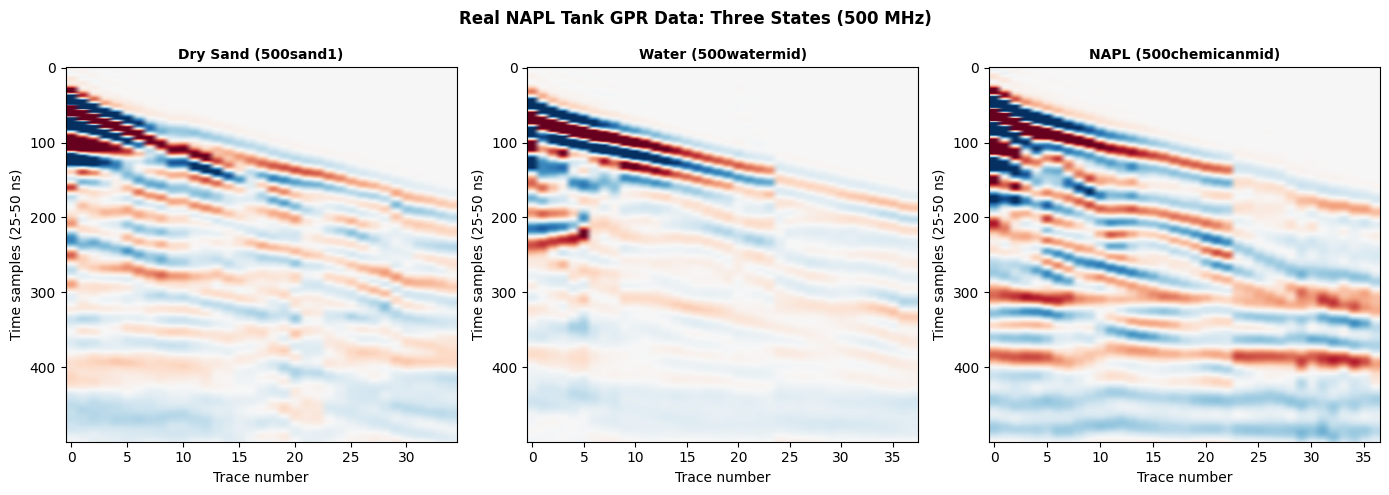

Real data saved to Drive.


In [5]:
def parse_real_gpr_file(filepath):
    """Parse real VNA GPR txt file -- handles (t,a) format with
    multiple traces concatenated, separated by time resets."""
    times_all, amps_all = [], []
    with open(filepath, 'r') as f:
        lines = f.readlines()
    for line in lines:
        line = line.strip().replace('(', '').replace(')', '')
        parts = line.split(',')
        if len(parts) == 2:
            try:
                times_all.append(float(parts[0]))
                amps_all.append(float(parts[1]))
            except ValueError:
                pass
    times_all = np.array(times_all)
    amps_all  = np.array(amps_all)
    resets = np.where(np.diff(times_all) < 0)[0]
    if len(resets) == 0:
        return times_all, amps_all.reshape(1, -1)
    boundaries = np.concatenate([[0], resets + 1, [len(times_all)]])
    traces, time_vec = [], None
    for i in range(len(boundaries) - 1):
        start, end = boundaries[i], boundaries[i + 1]
        traces.append(amps_all[start:end])
        if time_vec is None:
            time_vec = times_all[start:end]
    min_len = min(len(t) for t in traces)
    matrix  = np.array([t[:min_len] for t in traces])
    return time_vec[:min_len], matrix

# Load all three states
t_sand,  m_sand  = parse_real_gpr_file('500sand1.txt')
t_water, m_water = parse_real_gpr_file('500watermid.txt')
t_napl,  m_napl  = parse_real_gpr_file('500chemicanmid.txt')

print(f"Dry sand:  {m_sand.shape[0]} traces x {m_sand.shape[1]} samples")
print(f"Water:     {m_water.shape[0]} traces x {m_water.shape[1]} samples")
print(f"NAPL:      {m_napl.shape[0]} traces x {m_napl.shape[1]} samples")
print(f"Time window: {t_sand[0]*1e9:.2f} to {t_sand[-1]*1e9:.2f} ns")
print(f"Amplitude ranges:")
print(f"  Dry sand: {m_sand.min():.5f} to {m_sand.max():.5f}")
print(f"  Water:    {m_water.min():.5f} to {m_water.max():.5f}")
print(f"  NAPL:     {m_napl.min():.5f} to {m_napl.max():.5f}")

# Quick B-scan preview of all three
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
titles = ['Dry Sand (500sand1)', 'Water (500watermid)', 'NAPL (500chemicanmid)']
for ax, m, title in zip(axes, [m_sand, m_water, m_napl], titles):
    vmax = np.percentile(np.abs(m), 98)
    ax.imshow(m.T, cmap='RdBu', aspect='auto', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel('Trace number')
    ax.set_ylabel('Time samples (25-50 ns)')
plt.suptitle('Real NAPL Tank GPR Data: Three States (500 MHz)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Save to Drive
np.save('real_sand_data.npy',  m_sand)
np.save('real_water_data.npy', m_water)
np.save('real_napl_data.npy',  m_napl)
np.save('real_time_axis.npy',  t_sand)
print("Real data saved to Drive.")

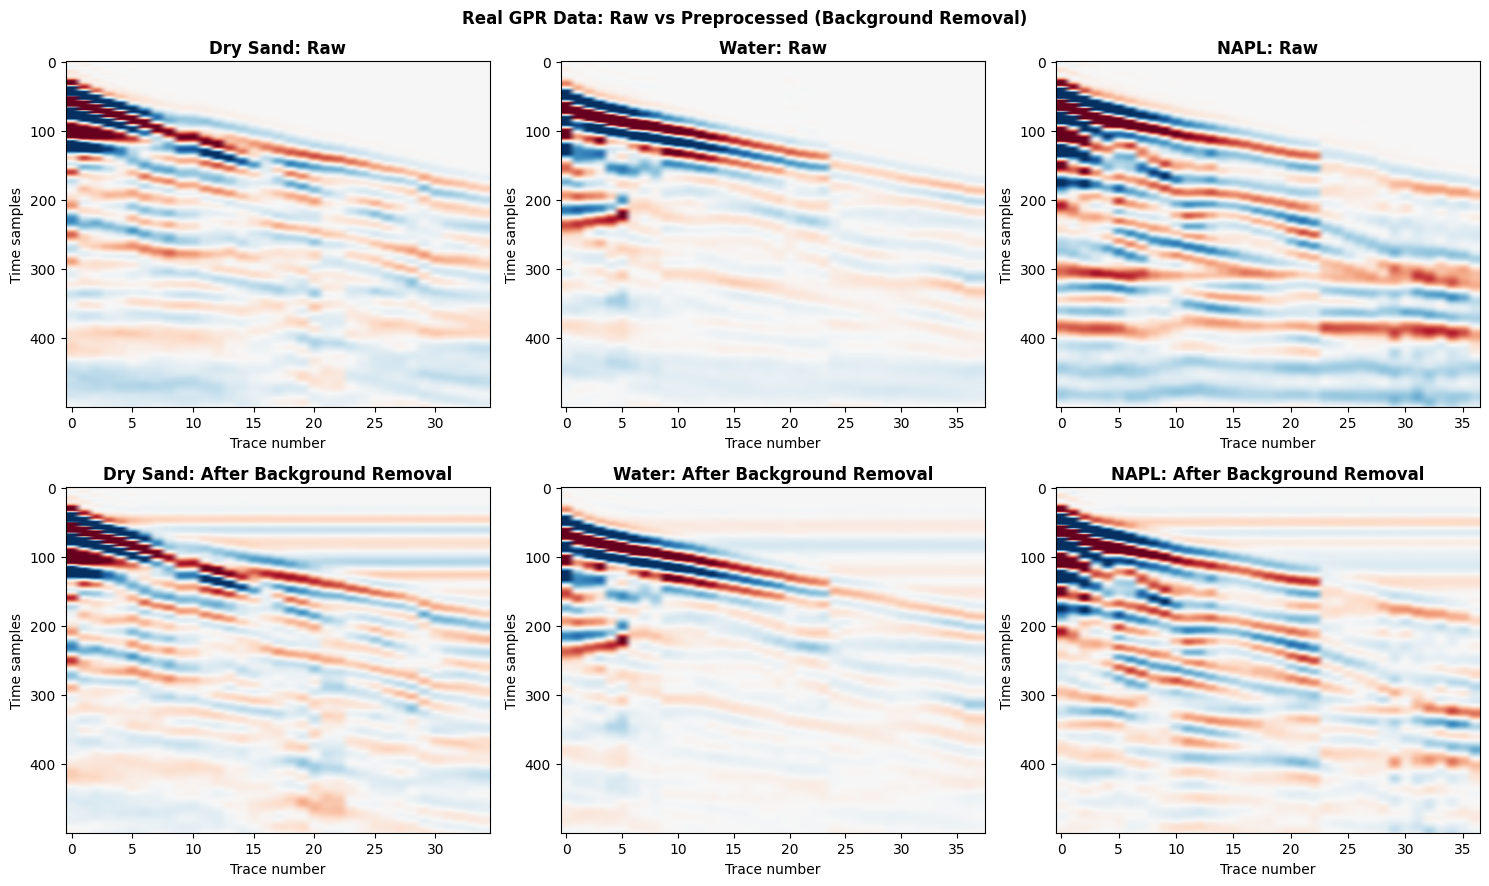

Preprocessed data saved to Drive.


In [6]:
def preprocess_gpr(matrix, n_traces_bg=None):
    """
    Standard GPR background removal: subtract the mean trace
    (averaged across all traces) from each individual trace.
    This removes the direct wave, antenna coupling response,
    and any coherent horizontal/diagonal banding that is
    consistent across the profile.
    """
    mean_trace = matrix.mean(axis=0, keepdims=True)
    processed  = matrix - mean_trace
    return processed.astype(np.float32)

m_sand_proc  = preprocess_gpr(m_sand)
m_water_proc = preprocess_gpr(m_water)
m_napl_proc  = preprocess_gpr(m_napl)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
titles = ['Dry Sand', 'Water', 'NAPL']

for j, (raw, proc, title) in enumerate(zip(
        [m_sand, m_water, m_napl],
        [m_sand_proc, m_water_proc, m_napl_proc],
        titles)):
    vmax_r = np.percentile(np.abs(raw),  98)
    vmax_p = np.percentile(np.abs(proc), 98)
    axes[0, j].imshow(raw.T,  cmap='RdBu', aspect='auto',
                       vmin=-vmax_r, vmax=vmax_r)
    axes[0, j].set_title(f'{title}: Raw',       fontweight='bold')
    axes[0, j].set_xlabel('Trace number')
    axes[0, j].set_ylabel('Time samples')

    axes[1, j].imshow(proc.T, cmap='RdBu', aspect='auto',
                       vmin=-vmax_p, vmax=vmax_p)
    axes[1, j].set_title(f'{title}: After Background Removal',
                          fontweight='bold')
    axes[1, j].set_xlabel('Trace number')
    axes[1, j].set_ylabel('Time samples')

plt.suptitle('Real GPR Data: Raw vs Preprocessed (Background Removal)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

np.save('real_sand_proc.npy',  m_sand_proc)
np.save('real_water_proc.npy', m_water_proc)
np.save('real_napl_proc.npy',  m_napl_proc)
print("Preprocessed data saved to Drive.")

Common trace count: 35
Data shape after resampling: (35, 64)
Diff water range: -0.01088 to 0.01000
Diff NAPL range:  -0.00622 to 0.00730


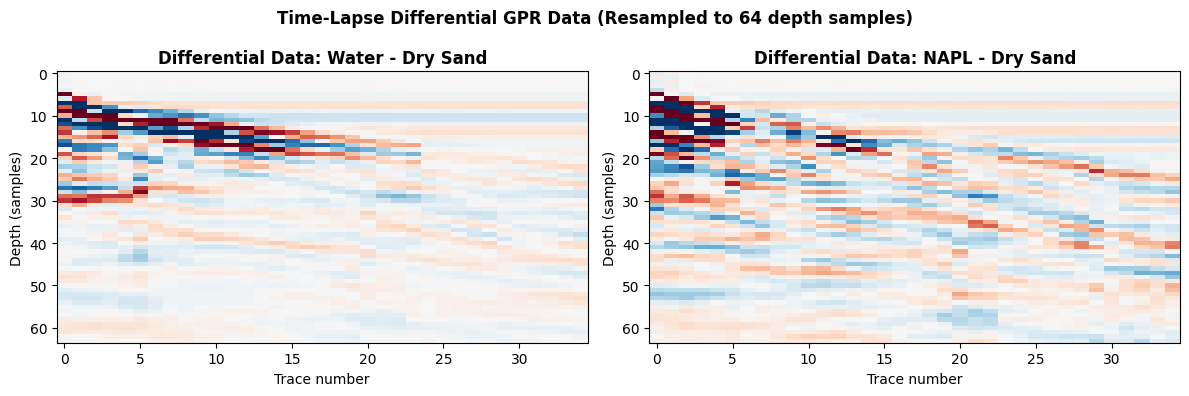

Differential data saved to Drive.


In [7]:
# ---- Resample from 500 to 64 time samples to match inversion grid ----
from scipy.interpolate import interp1d

def resample_traces(matrix, n_out=64):
    """Resample each trace from original time samples to n_out samples."""
    n_traces, n_in = matrix.shape
    x_old = np.linspace(0, 1, n_in)
    x_new = np.linspace(0, 1, n_out)
    out = np.zeros((n_traces, n_out), dtype=np.float32)
    for i in range(n_traces):
        f = interp1d(x_old, matrix[i], kind='linear')
        out[i] = f(x_new)
    return out

# Resample all three states to 64 depth samples
sand_64  = resample_traces(m_sand_proc,  n_out=64)
water_64 = resample_traces(m_water_proc, n_out=64)
napl_64  = resample_traces(m_napl_proc,  n_out=64)

# ---- Time-lapse difference data ----
# Pad/trim to same trace count (use minimum)
n_min = min(sand_64.shape[0], water_64.shape[0], napl_64.shape[0])
sand_64  = sand_64[:n_min]
water_64 = water_64[:n_min]
napl_64  = napl_64[:n_min]

diff_water = water_64 - sand_64   # water - dry: shows water infiltration
diff_napl  = napl_64  - sand_64   # NAPL  - dry: shows contamination signal

print(f"Common trace count: {n_min}")
print(f"Data shape after resampling: {sand_64.shape}")
print(f"Diff water range: {diff_water.min():.5f} to {diff_water.max():.5f}")
print(f"Diff NAPL range:  {diff_napl.min():.5f} to {diff_napl.max():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vmax_w = np.percentile(np.abs(diff_water), 98)
vmax_n = np.percentile(np.abs(diff_napl),  98)
axes[0].imshow(diff_water.T, cmap='RdBu', aspect='auto',
               vmin=-vmax_w, vmax=vmax_w)
axes[0].set_title('Differential Data: Water - Dry Sand', fontweight='bold')
axes[0].set_xlabel('Trace number'); axes[0].set_ylabel('Depth (samples)')
axes[1].imshow(diff_napl.T, cmap='RdBu', aspect='auto',
               vmin=-vmax_n, vmax=vmax_n)
axes[1].set_title('Differential Data: NAPL - Dry Sand', fontweight='bold')
axes[1].set_xlabel('Trace number'); axes[1].set_ylabel('Depth (samples)')
plt.suptitle('Time-Lapse Differential GPR Data (Resampled to 64 depth samples)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

np.save('diff_water_64.npy', diff_water)
np.save('diff_napl_64.npy',  diff_napl)
np.save('sand_64.npy',       sand_64)
print("Differential data saved to Drive.")

Reflection arrival times (ns) -- first 10 traces per state:
Dry sand: [28.01 28.11 28.31 28.61 28.81 29.16 29.51 29.76 30.11 30.76]
Water:    [28.31 28.51 28.91 29.16 29.26 29.41 29.66 29.91 29.96 30.41]
NAPL:     [28.01 28.16 28.56 28.81 28.96 29.06 29.31 29.56 29.71 29.91]

Estimated eps_r from travel time:
Dry sand: mean=91.53, range=70.59-148.95
Water:    mean=92.76, range=72.11-151.90
NAPL:     mean=103.99, range=70.59-182.17


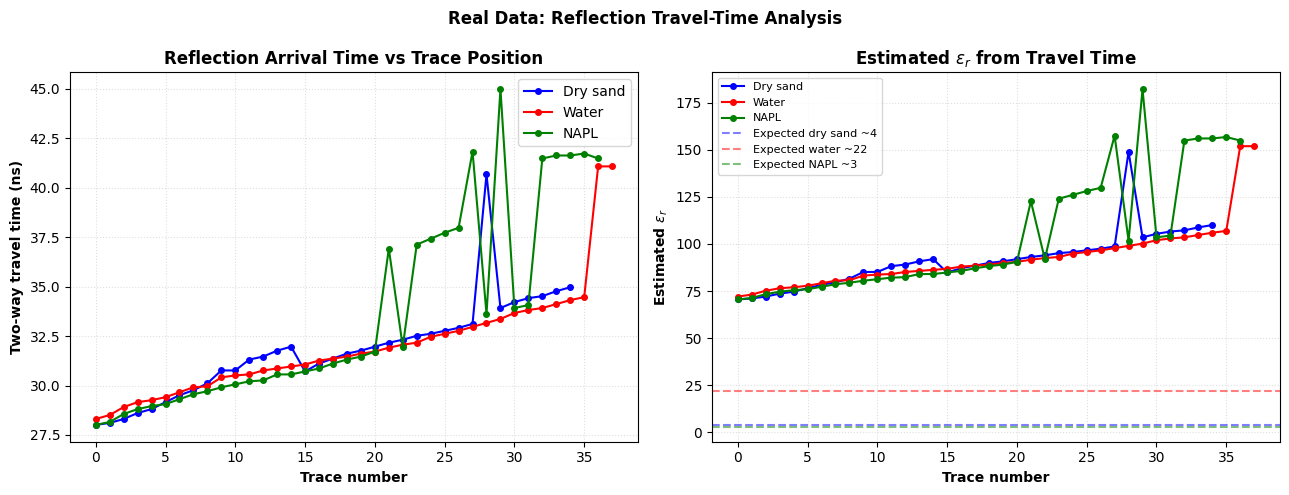


Physical check:
Water/Sand eps_r ratio: 1.01 (expected ~5-6)
NAPL/Sand eps_r ratio:  1.14 (expected ~0.5-1.0)


In [8]:
from scipy.signal import hilbert
from scipy.ndimage import gaussian_filter1d

def pick_reflection_time(trace, t_axis, t_start_ns=28, t_end_ns=45):
    """
    Pick the dominant reflection arrival time in a GPR trace using
    the envelope (Hilbert transform magnitude). Searches within a
    physically meaningful time window to avoid the direct wave
    (which arrives in the first ~27 ns) and the tank floor reflection
    (which arrives after ~45 ns).
    """
    t_ns = t_axis * 1e9
    mask = (t_ns >= t_start_ns) & (t_ns <= t_end_ns)
    envelope = np.abs(hilbert(trace))
    env_window = envelope.copy()
    env_window[~mask] = 0
    peak_idx = np.argmax(env_window)
    return t_ns[peak_idx], peak_idx

def compute_travel_time_map(matrix, t_axis, t_start_ns=28, t_end_ns=45):
    """Pick reflection arrival time for every trace."""
    n_traces, n_samples = matrix.shape
    t_pick = np.zeros(n_traces)
    for i in range(n_traces):
        t_pick[i], _ = pick_reflection_time(matrix[i], t_axis, t_start_ns, t_end_ns)
    return t_pick

# Pick reflection times for all three states
t_pick_sand  = compute_travel_time_map(m_sand_proc,  t_sand)
t_pick_water = compute_travel_time_map(m_water_proc, t_sand)
t_pick_napl  = compute_travel_time_map(m_napl_proc,  t_sand)

print("Reflection arrival times (ns) -- first 10 traces per state:")
print(f"Dry sand: {t_pick_sand[:10].round(2)}")
print(f"Water:    {t_pick_water[:10].round(2)}")
print(f"NAPL:     {t_pick_napl[:10].round(2)}")

# Physical interpretation:
# Two-way travel time t = 2*d / v = 2*d*sqrt(eps_r) / c
# If we assume reflector depth d is constant (tank floor at ~1m depth),
# we can estimate eps_r from the travel time:
# eps_r = (t*c / (2*d))^2
c = 3e8  # m/s
d = 0.5  # assumed reflector depth in metres (tank is 2m deep, target ~0.5m)

eps_est_sand  = ((t_pick_sand  * 1e-9 * c) / (2 * d)) ** 2
eps_est_water = ((t_pick_water * 1e-9 * c) / (2 * d)) ** 2
eps_est_napl  = ((t_pick_napl  * 1e-9 * c) / (2 * d)) ** 2

print(f"\nEstimated eps_r from travel time:")
print(f"Dry sand: mean={eps_est_sand.mean():.2f}, range={eps_est_sand.min():.2f}-{eps_est_sand.max():.2f}")
print(f"Water:    mean={eps_est_water.mean():.2f}, range={eps_est_water.min():.2f}-{eps_est_water.max():.2f}")
print(f"NAPL:     mean={eps_est_napl.mean():.2f}, range={eps_est_napl.min():.2f}-{eps_est_napl.max():.2f}")

# Plot picked times vs trace position
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(t_pick_sand,  'b-o', ms=4, label='Dry sand')
axes[0].plot(t_pick_water, 'r-o', ms=4, label='Water')
axes[0].plot(t_pick_napl,  'g-o', ms=4, label='NAPL')
axes[0].set_xlabel('Trace number', fontweight='bold')
axes[0].set_ylabel('Two-way travel time (ns)', fontweight='bold')
axes[0].set_title('Reflection Arrival Time vs Trace Position', fontweight='bold')
axes[0].legend(); axes[0].grid(True, linestyle=':', alpha=0.4)

axes[1].plot(eps_est_sand,  'b-o', ms=4, label='Dry sand')
axes[1].plot(eps_est_water, 'r-o', ms=4, label='Water')
axes[1].plot(eps_est_napl,  'g-o', ms=4, label='NAPL')
axes[1].axhline(4,  color='b', linestyle='--', alpha=0.5, label='Expected dry sand ~4')
axes[1].axhline(22, color='r', linestyle='--', alpha=0.5, label='Expected water ~22')
axes[1].axhline(3,  color='g', linestyle='--', alpha=0.5, label='Expected NAPL ~3')
axes[1].set_xlabel('Trace number', fontweight='bold')
axes[1].set_ylabel(r'Estimated $\varepsilon_r$', fontweight='bold')
axes[1].set_title(r'Estimated $\varepsilon_r$ from Travel Time', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(True, linestyle=':', alpha=0.4)

plt.suptitle('Real Data: Reflection Travel-Time Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPhysical check:")
print(f"Water/Sand eps_r ratio: {eps_est_water.mean()/eps_est_sand.mean():.2f} (expected ~5-6)")
print(f"NAPL/Sand eps_r ratio:  {eps_est_napl.mean()/eps_est_sand.mean():.2f} (expected ~0.5-1.0)")

In [9]:
import h5py
from scipy.signal import hilbert

def read_gprmax_trace(filepath, rx_component='Ez'):
    """Read single-trace time-domain field from gprMax HDF5 output."""
    with h5py.File(filepath, 'r') as f:
        dt         = f.attrs['dt']
        iterations = f.attrs['Iterations']
        field      = f['rxs']['rx1'][rx_component][:]
        time       = np.arange(iterations) * dt
    return time, field

def synthesize_trace(sim_time, sim_field,
                     f_start=1e6, f_stop=1.2e9, n_points=500,
                     t_start=25e-9, t_stop=50e-9):
    """Convert gprMax broadband time-domain output to VNA-equivalent
    time-domain trace (same pipeline used in Figure 2 validation)."""
    dt       = sim_time[1] - sim_time[0]
    n        = len(sim_field)
    spectrum = np.fft.rfft(sim_field)
    freqs    = np.fft.rfftfreq(n, d=dt)
    vna_freqs   = np.linspace(f_start, f_stop, n_points)
    real_interp = np.interp(vna_freqs, freqs, spectrum.real)
    imag_interp = np.interp(vna_freqs, freqs, spectrum.imag)
    vna_spectrum = real_interp + 1j * imag_interp
    time_domain  = np.fft.irfft(vna_spectrum, n=n_points * 2)
    dt_recon     = 1.0 / (2 * f_stop)
    recon_time   = np.arange(len(time_domain)) * dt_recon
    target_time  = np.linspace(t_start, t_stop, n_points)
    resampled    = np.interp(target_time, recon_time,
                             time_domain[:len(recon_time)])
    return target_time, resampled

print("Figure 9 analysis functions ready.")
print("Waiting for gprMax simulations to complete...")
print("Files needed:")
print("  D:\\GPR  data\\PINN Paper\\Simulation\\tank_dry_sand_v2.out  (DONE)")
print("  D:\\GPR  data\\PINN Paper\\Simulation\\tank_water_state.out  (DONE)")
print("  D:\\GPR  data\\PINN Paper\\Simulation\\tank_napl_state.out   (RUNNING...)")

Figure 9 analysis functions ready.
Waiting for gprMax simulations to complete...
Files needed:
  D:\GPR  data\PINN Paper\Simulation\tank_dry_sand_v2.out  (DONE)
  D:\GPR  data\PINN Paper\Simulation\tank_water_state.out  (DONE)
  D:\GPR  data\PINN Paper\Simulation\tank_napl_state.out   (RUNNING...)


In [10]:
from google.colab import files
uploaded = files.upload()

Saving tank_dry_sand_v2.out to tank_dry_sand_v2.out


In [11]:
from google.colab import files
uploaded = files.upload()

Saving tank_dry_sand_v2.out to tank_dry_sand_v2 (1).out
Saving tank_napl_state.out to tank_napl_state.out
Saving tank_water_state.out to tank_water_state.out


In [12]:
import os
for f in ['tank_dry_sand_v2.out', 'tank_water_state.out', 'tank_napl_state.out']:
    size = os.path.getsize(f) / 1024 / 1024
    print(f"{f}: {size:.1f} MB")

tank_dry_sand_v2.out: 2.0 MB
tank_water_state.out: 2.0 MB
tank_napl_state.out: 2.0 MB


Simulation time window: 0 to 416.0 ns
Time samples: 88187

Simulated difference ranges:
  Water - Dry: -0.6576 to 0.9257
  NAPL  - Dry: -0.6270  to 0.9212

Real data difference ranges:
  Water - Dry: -0.5366 to 0.4419
  NAPL  - Dry: -0.7975  to 0.7555

Correlation (simulated vs real difference):
  Water state: r = 0.2640
  NAPL  state: r = 0.3487


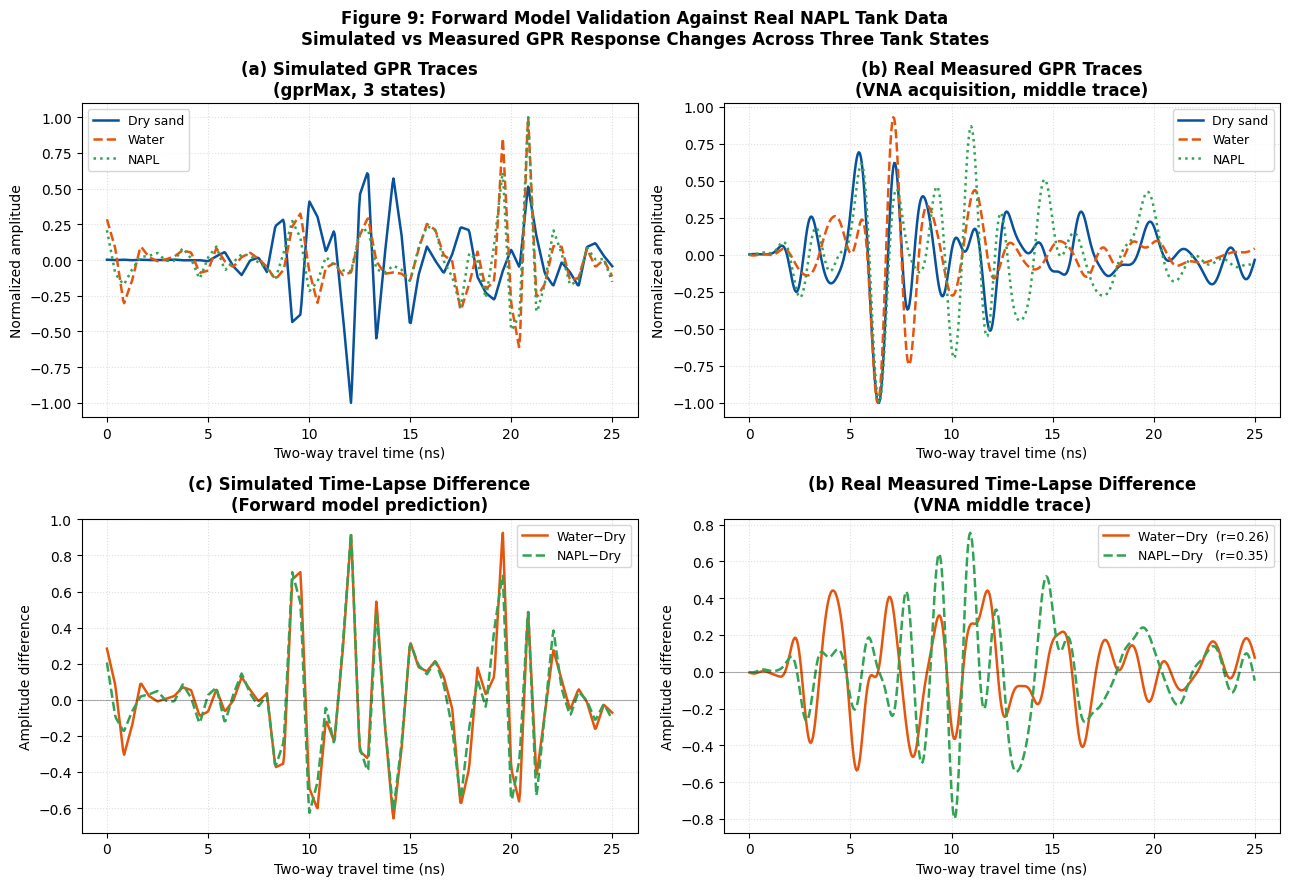

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Figure 9 saved. Correlations: Water r=0.2640, NAPL r=0.3487


In [13]:
# ---- Read all three simulated traces ----
t_sim, field_dry   = read_gprmax_trace('tank_dry_sand_v2.out')
t_sim, field_water = read_gprmax_trace('tank_water_state.out')
t_sim, field_napl  = read_gprmax_trace('tank_napl_state.out')

print(f"Simulation time window: 0 to {t_sim[-1]*1e9:.1f} ns")
print(f"Time samples: {len(t_sim)}")

# ---- Convert to VNA-equivalent time-domain traces ----
vna_t, trace_dry   = synthesize_trace(t_sim, field_dry)
vna_t, trace_water = synthesize_trace(t_sim, field_water)
vna_t, trace_napl  = synthesize_trace(t_sim, field_napl)

# Normalize each to its own peak for shape comparison
def norm(x): return x / np.max(np.abs(x))

trace_dry_n   = norm(trace_dry)
trace_water_n = norm(trace_water)
trace_napl_n  = norm(trace_napl)

# ---- Simulated differences (state - dry baseline) ----
diff_sim_water = trace_water_n - trace_dry_n
diff_sim_napl  = trace_napl_n  - trace_dry_n

print(f"\nSimulated difference ranges:")
print(f"  Water - Dry: {diff_sim_water.min():.4f} to {diff_sim_water.max():.4f}")
print(f"  NAPL  - Dry: {diff_sim_napl.min():.4f}  to {diff_sim_napl.max():.4f}")

# ---- Real data differences ----
# Use middle trace from each real profile
mid_sand  = m_sand_proc[len(m_sand_proc)  // 2]
mid_water = m_water_proc[len(m_water_proc) // 2]
mid_napl  = m_napl_proc[len(m_napl_proc)  // 2]

# Resample real traces from 500 to match VNA time axis (500 pts, 25-50ns)
from scipy.interpolate import interp1d
t_real_ns = t_sand * 1e9  # already in seconds, convert to ns
t_vna_ns  = vna_t  * 1e9

def resample_to_vna(trace, t_real_ns, t_vna_ns):
    f = interp1d(t_real_ns, trace, kind='linear',
                 bounds_error=False, fill_value=0.0)
    return f(t_vna_ns)

real_dry_r   = resample_to_vna(mid_sand,  t_real_ns, t_vna_ns)
real_water_r = resample_to_vna(mid_water, t_real_ns, t_vna_ns)
real_napl_r  = resample_to_vna(mid_napl,  t_real_ns, t_vna_ns)

real_dry_n   = norm(real_dry_r)
real_water_n = norm(real_water_r)
real_napl_n  = norm(real_napl_r)

diff_real_water = real_water_n - real_dry_n
diff_real_napl  = real_napl_n  - real_dry_n

print(f"\nReal data difference ranges:")
print(f"  Water - Dry: {diff_real_water.min():.4f} to {diff_real_water.max():.4f}")
print(f"  NAPL  - Dry: {diff_real_napl.min():.4f}  to {diff_real_napl.max():.4f}")

# ---- Correlation between simulated and real differences ----
corr_water = np.corrcoef(diff_sim_water, diff_real_water)[0, 1]
corr_napl  = np.corrcoef(diff_sim_napl,  diff_real_napl)[0, 1]

print(f"\nCorrelation (simulated vs real difference):")
print(f"  Water state: r = {corr_water:.4f}")
print(f"  NAPL  state: r = {corr_napl:.4f}")

# ---- Figure 9: four-panel comparison ----
t_plot = t_vna_ns - t_vna_ns[0]  # shift to start at 0

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel 1: simulated traces (absolute)
axes[0, 0].plot(t_plot, trace_dry_n,   color='#08519c', lw=1.8, label='Dry sand')
axes[0, 0].plot(t_plot, trace_water_n, color='#e6550d', lw=1.8, label='Water', ls='--')
axes[0, 0].plot(t_plot, trace_napl_n,  color='#31a354', lw=1.8, label='NAPL',  ls=':')
axes[0, 0].set_title('(a) Simulated GPR Traces\n(gprMax, 3 states)',
                      fontweight='bold')
axes[0, 0].set_xlabel('Two-way travel time (ns)')
axes[0, 0].set_ylabel('Normalized amplitude')
axes[0, 0].legend(fontsize=9); axes[0, 0].grid(True, ls=':', alpha=0.4)

# Panel 2: real traces (absolute)
axes[0, 1].plot(t_plot, real_dry_n,   color='#08519c', lw=1.8, label='Dry sand')
axes[0, 1].plot(t_plot, real_water_n, color='#e6550d', lw=1.8, label='Water', ls='--')
axes[0, 1].plot(t_plot, real_napl_n,  color='#31a354', lw=1.8, label='NAPL',  ls=':')
axes[0, 1].set_title('(b) Real Measured GPR Traces\n(VNA acquisition, middle trace)',
                      fontweight='bold')
axes[0, 1].set_xlabel('Two-way travel time (ns)')
axes[0, 1].set_ylabel('Normalized amplitude')
axes[0, 1].legend(fontsize=9); axes[0, 1].grid(True, ls=':', alpha=0.4)

# Panel 3: simulated difference
axes[1, 0].plot(t_plot, diff_sim_water, color='#e6550d', lw=1.8,
                label=f'Water−Dry')
axes[1, 0].plot(t_plot, diff_sim_napl,  color='#31a354', lw=1.8,
                label=f'NAPL−Dry', ls='--')
axes[1, 0].axhline(0, color='black', lw=0.8, ls='-', alpha=0.3)
axes[1, 0].set_title('(c) Simulated Time-Lapse Difference\n(Forward model prediction)',
                      fontweight='bold')
axes[1, 0].set_xlabel('Two-way travel time (ns)')
axes[1, 0].set_ylabel('Amplitude difference')
axes[1, 0].legend(fontsize=9); axes[1, 0].grid(True, ls=':', alpha=0.4)

# Panel 4: real difference
axes[1, 1].plot(t_plot, diff_real_water, color='#e6550d', lw=1.8,
                label=f'Water−Dry  (r={corr_water:.2f})')
axes[1, 1].plot(t_plot, diff_real_napl,  color='#31a354', lw=1.8,
                label=f'NAPL−Dry   (r={corr_napl:.2f})', ls='--')
axes[1, 1].axhline(0, color='black', lw=0.8, ls='-', alpha=0.3)
axes[1, 1].set_title('(b) Real Measured Time-Lapse Difference\n(VNA middle trace)',
                      fontweight='bold')
axes[1, 1].set_xlabel('Two-way travel time (ns)')
axes[1, 1].set_ylabel('Amplitude difference')
axes[1, 1].legend(fontsize=9); axes[1, 1].grid(True, ls=':', alpha=0.4)

fig.suptitle('Figure 9: Forward Model Validation Against Real NAPL Tank Data\n'
             'Simulated vs Measured GPR Response Changes Across Three Tank States',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figure9_real_data_validation.png', dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('figure9_real_data_validation.png')
print(f"\nFigure 9 saved. Correlations: Water r={corr_water:.4f}, NAPL r={corr_napl:.4f}")

In [14]:
np.save('figure9_sim_traces.npy',
        np.stack([trace_dry_n, trace_water_n, trace_napl_n]))
np.save('figure9_real_traces.npy',
        np.stack([real_dry_n, real_water_n, real_napl_n]))
np.save('figure9_correlations.npy',
        np.array([corr_water, corr_napl]))
print("Figure 9 data saved to Drive.")
print(f"Final correlations: Water r={corr_water:.4f}, NAPL r={corr_napl:.4f}")

Figure 9 data saved to Drive.
Final correlations: Water r=0.2640, NAPL r=0.3487
